In [1]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [3]:
train_images.shape

(50000, 32, 32, 3)

In [4]:
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

In [5]:
# DO NOT convert to one-hot
# train_labels remains integers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))  # Add this
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))  # Add this
model.add(layers.Dense(10))

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(train_images, train_labels, epochs=20,
                    validation_split=0.1, batch_size=128)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 153ms/step - accuracy: 0.3185 - loss: 1.8224 - val_accuracy: 0.4540 - val_loss: 1.5125
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 153ms/step - accuracy: 0.4608 - loss: 1.4749 - val_accuracy: 0.5286 - val_loss: 1.2995
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 83s 155ms/step - accuracy: 0.5215 - loss: 1.3272 - val_accuracy: 0.5866 - val_loss: 1.1601
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.5611 - loss: 1.2336 - val_accuracy: 0.6218 - val_loss: 1.0845
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 84s 160ms/step - accuracy: 0.5815 - loss: 1.1704 - val_accuracy: 0.6388 - val_loss: 1.0353
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 83s 163ms/step - accuracy: 0.6013 - loss: 1.1184 - val_accuracy: 0.6570 - val_loss: 0.9912
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 155ms/step - accuracy: 0.6201 - loss: 1.0797 - val_accuracy: 0.6448 - val_loss: 1.0090
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 153ms/step - accuracy: 0.6348 - loss: 1

313/313 - 4s - 14ms/step - accuracy: 0.7433 - loss: 0.7556


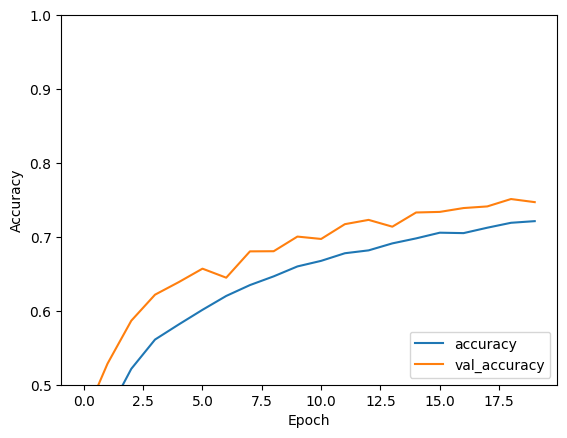

In [8]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [9]:
print(test_acc)

0.7433000206947327
